In [ ]:
import pandas as pd
from datasets import Dataset
import torch
from transformers import pipeline
from tqdm import tqdm
from transformers.pipelines.pt_utils import KeyDataset
from metrics import return_all_metrics, most_common_words, most_common_fn, most_common_fp

In [2]:
ds = Dataset.from_csv("../data/edible_test_set.csv")

In [3]:
ds

Dataset({
    features: ['Unnamed: 0', 'product_name', 'manual_label'],
    num_rows: 100
})

In [4]:
classifier = pipeline(
    "zero-shot-classification", 
    model="MoritzLaurer/mDeBERTa-v3-base-mnli-xnli",
    batch_size=16   
)

Loading weights: 100%|██████████| 202/202 [00:00<00:00, 4587.51it/s]


In [5]:
result = []

In [6]:
labels = [
    "Lebensmittel für Menschen",
    "kein Lebensmittel"
]

In [7]:
for output in tqdm(
    classifier(
        KeyDataset(ds, "product_name"),
        candidate_labels=labels,
        hypothesis_template="Dieser Artikel ist {}.",
        batch_size=16
    ),
    total=len(ds)
):
    result.append(output)

100%|██████████| 100/100 [00:57<00:00,  1.74it/s]


In [8]:
labels = [r['labels']=='Lebensmittel für Menschen' for r in result]

In [9]:
def get_classes(ds, labels):

    classes = {
        'TP': [],
        'FP': [],
        'TN': [],
        'FN': []
    }

    for i, row in enumerate(ds):

        if labels[i] == row["manual_label"]:
            if labels[i]:
                classes["TP"].append(i)
            else:
                classes["TN"].append(i)

        else:
            if labels[i]:
                classes["FP"].append(i)
            else:
                classes["FN"].append(i)

    return classes

In [10]:
classes = get_classes(ds, labels)

In [13]:
metrics = return_all_metrics(classes)

TypeError: object of type 'int' has no len()

In [24]:
metrics

(0.21, 0.0, 0.0, 0.9999995238097505)

In [25]:
from sklearn import metrics

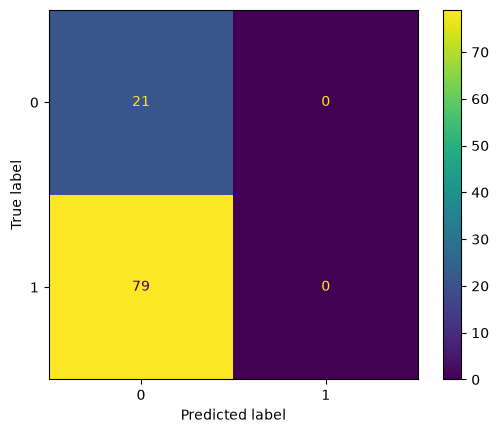

In [30]:
confusion_matrix = metrics.confusion_matrix(list(ds["manual_label"]), labels)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [0, 1])
cm_display.plot()